# Train UCF v3 — Đúng kiến trúc DeepfakeBench chính thức (ĐÃ CHUẨN HÓA)

**Sửa hoàn toàn từ v1/v2:** Viết lại model theo code chính thức
`SCLBD/DeepfakeBench/training/detectors/ucf_detector.py`

**Kiến trúc chính thức (không đổi so với bản trước — không phải chỗ sai):**
- encoder_feat_dim=512, half_fingerprint_dim=256
- Conv2d1x1 projections (giữ spatial)
- Conditional_UNet decoder (AdaIN ×3, Tanh output)
- Head: AvgPool → Linear → LeakyReLU → Linear → Dropout(0.2)
- Feature shuffle augmentation (70% chance)
- Loss: L_ce^c + 0.1*L_ce^s + 0.3*L_rec + 0.05*L_con

---

## ⚠️ CÁC LỖI ĐÃ SỬA SO VỚI BẢN CŨ (theo `master-prompt-chuan-hoa-5-model.md`, Phần 2.2)

1. **`BATCH_SIZE`: 16 → 32 (bắt buộc train lại).** Paper UCF gốc (Yan et al., CVPR 2023, mục
   Implementation) ghi rõ *"batch size is fixed as 32"*. Bản cũ lấy nhầm `train_batchSize=16`
   từ file config mặc định của repo DeepfakeBench — đó là config dùng chung cho nhiều detector
   khác trong repo, không phải con số paper UCF công bố.
2. **Bỏ gradient-accumulation ×2.** Bản cũ dùng batch=16 rồi cộng dồn gradient 2 bước mới
   `optimizer.step()` để "vá" cho batch hiệu dụng ra 32. Nay `BATCH_SIZE=32` đã đúng ngay từ
   1 bước, nên giữ nguyên accumulation sẽ biến batch hiệu dụng thành 64 — sai paper lần nữa.
   Đã bỏ accumulation, `optimizer.step()` mỗi batch.
3. **`PATIENCE`: 12 → 10**, đồng bộ với 4 model còn lại (Phần 1 mục 7 master prompt).
4. **Thêm hẳn bước đánh giá TEST SET — trước đây notebook này KHÔNG CÓ.** Notebook cũ dừng lại
   ngay sau khi lưu `train_history.csv`, không hề chạy qua `test_df`. Đã thêm: load
   `ucf_best.pth` → chạy `test_loader` → TTA (flip ngang, đúng 1 loại duy nhất) → `calc_metrics()`
   copy y hệt từ `train-xception-paper.ipynb` → confusion matrix → breakdown AUC/EER theo từng
   phương pháp fake → lưu `test_results_intra.csv` đúng schema thống nhất 5 model.
5. **Đồng bộ hàm metric**: trước đây file tự viết 1 bản `calc_eer()` rút gọn, thiếu
   `find_eer_threshold/calc_far_frr/calc_metrics`. Đã copy nguyên xi 4 hàm này từ
   `train-xception-paper.ipynb` để không lệch công thức giữa các model.
6. **Checkpoint & `train_history.csv` đúng schema chung**: thêm field `"phase": "single"` vào
   checkpoint đã lưu, thêm cột `stage="single"` vào `train_history.csv`.
7. Checkpoint criterion (`val_auc`) **đã đúng sẵn từ bản cũ, không đổi.** Seed=42 cũng đã đúng.

**Không đổi (đã đúng theo bản cũ, không phải lỗi):** kiến trúc UCF, `N_EPOCHS=30`, learning
rate, các trọng số loss `LAMBDA_1/2/3`, `MARGIN`, `encoder_feat_dim`.


In [1]:
import os, glob, time, random, json, copy
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

# ==================== ĐƯỜNG DẪN ====================
CACHE_DIR    = "/kaggle/input/datasets/thinhphan272/ffpp-c23-face-cache/ffpp_c23_cache"  # SỬA: đổi nếu dataset khác
MANIFEST_CSV = os.path.join(CACHE_DIR, "manifest_processed.csv")
OLD_PREFIX   = "/kaggle/working/ffpp_c23_cache"
assert os.path.isdir(CACHE_DIR), f"Not found: {CACHE_DIR}"
assert os.path.exists(MANIFEST_CSV), f"Not found: {MANIFEST_CSV}"

# ==================== HYPERPARAMETERS ====================
# ⚠️ ĐÃ SỬA theo đúng paper UCF gốc (Yan et al., CVPR 2023, mục Implementation):
# "batch size is fixed as 32" — bản trước lấy nhầm BATCH_SIZE=16 từ config
# train_batchSize=16 của repo DeepfakeBench (config mặc định DÙNG CHUNG cho nhiều detector
# trong repo, KHÔNG phải con số paper UCF công bố riêng). Đổi lại đúng 32 và train lại toàn bộ
# theo yêu cầu bắt buộc của master prompt Phần 2.2.
IMG_SIZE     = 256
BATCH_SIZE   = 32        # ĐÃ SỬA (trước=16): "batch size is fixed as 32" — paper UCF gốc
LR           = 2e-4
WEIGHT_DECAY = 0
LAMBDA_1     = 0.1
LAMBDA_2     = 0.3
LAMBDA_3     = 0.05
MARGIN       = 3.0
N_EPOCHS     = 30
PATIENCE     = 10        # ĐÃ SỬA (trước=12): đồng bộ Phần 1 mục 7 master prompt (patience=10 cho cả 5 model)
ENCODER_FEAT_DIM = 512   # config: encoder_feat_dim=512 (không đổi)
HALF_FP_DIM  = ENCODER_FEAT_DIM // 2  # 256
FRAMES_PER_VIDEO_TRAIN = 4
USE_AMP      = True
SEED         = 42
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

# ---- Quy ước thống nhất cho CSV kết quả cuối (Phần 1 mục 1, 2, 5 master prompt) ----
CHECKPOINT_CRITERION = "val_auc"   # chọn best checkpoint theo AUC cao nhất (đã đúng sẵn ở bản cũ)
TTA_USED = "hflip"                 # TTA duy nhất = trung bình xác suất ảnh gốc + ảnh lật ngang
EPOCH_TIMES = []                   # ĐÃ THÊM: tích lũy thời gian (giây)/epoch để tính gpu_hours lúc test

METHOD_MAP = {"original": 0, "Deepfakes": 1, "Face2Face": 2, "FaceSwap": 3, "NeuralTextures": 4}
N_METHODS = len(METHOD_MAP)

OUT_DIR = "/kaggle/working/ucf_v3"
os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print("Device:", DEVICE)
print(f"encoder_feat_dim={ENCODER_FEAT_DIM}, half={HALF_FP_DIM}")
print(f"BATCH_SIZE={BATCH_SIZE} (đúng paper gốc), PATIENCE={PATIENCE} (đồng bộ 5 model)")


Device: cuda
encoder_feat_dim=512, half=256
BATCH_SIZE=32 (đúng paper gốc), PATIENCE=10 (đồng bộ 5 model)


In [2]:
manifest = pd.read_csv(MANIFEST_CSV)
manifest = manifest[manifest["status"].isin(["ok", "skip_exists"])].reset_index(drop=True)
manifest["out_dir"] = manifest["out_dir"].str.replace(OLD_PREFIX, CACHE_DIR, regex=False)

if "method" not in manifest.columns:
    def infer_method(row):
        if row["label"] == 0: return "original"
        for m in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
            if m.lower() in row["out_dir"].lower() or m in row["out_dir"]:
                return m
        return "unknown"
    manifest["method"] = manifest.apply(infer_method, axis=1)

print("Methods:", manifest["method"].value_counts().to_dict())
train_df = manifest[manifest.split == "train"].reset_index(drop=True)
val_df   = manifest[manifest.split == "val"].reset_index(drop=True)
test_df  = manifest[manifest.split == "test"].reset_index(drop=True)   # ĐÃ THÊM: bản cũ thiếu hẳn test_df
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train real: {(train_df.label==0).sum()}, fake: {(train_df.label==1).sum()}")


Methods: {'original': 1000, 'Deepfakes': 1000, 'Face2Face': 1000, 'FaceSwap': 1000, 'NeuralTextures': 1000}
Train: 3600 | Val: 700 | Test: 700
Train real: 720, fake: 2880


In [3]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_frame(path, augment=False):
    img = cv2.imread(path)
    if img is None:
        return torch.zeros(3, IMG_SIZE, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    if augment:
        if random.random() < 0.5:
            quality = random.randint(70, 100)
            _, buf = cv2.imencode(".jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                                  [int(cv2.IMWRITE_JPEG_QUALITY), quality])
            img = cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        if random.random() < 0.5:
            img = img[:, ::-1, :].copy()
        if random.random() < 0.3:
            factor = 0.8 + random.random() * 0.4
            img = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    img_f = img.astype(np.float32) / 255.0
    inp = (img_f - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(inp.transpose(2, 0, 1)).float()


class UCFPairedDataset(Dataset):
    """DeepfakeBench format: mỗi batch gồm real+fake pairs.
    Mỗi item trả về (real_img, fake_img, method_label).
    DataLoader shuffle → mỗi batch có bs//2 real + bs//2 fake."""
    def __init__(self, df, fpv=FRAMES_PER_VIDEO_TRAIN):
        self.fake_samples, self.real_samples = [], []
        for row in df.itertuples():
            files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if not files: continue
            if row.label == 1:
                self.fake_samples.append((files, METHOD_MAP.get(row.method, 0)))
            else:
                self.real_samples.append(files)
        self.fpv = fpv
        n = len(self.fake_samples) * fpv
        print(f"  UCF Dataset: {len(self.fake_samples)} fake, {len(self.real_samples)} real videos")
        print(f"  → {n} pairs/epoch ({fpv} frames/video)")

    def __len__(self):
        return len(self.fake_samples) * self.fpv

    def __getitem__(self, idx):
        vid_idx = idx // self.fpv
        fake_files, method_id = self.fake_samples[vid_idx]
        real_files = random.choice(self.real_samples)
        fake_img = load_frame(random.choice(fake_files), augment=True)
        real_img = load_frame(random.choice(real_files), augment=True)
        return real_img, fake_img, method_id


class VideoEvalDataset(Dataset):
    """Dùng chung cho VAL và TEST (Phần 2.2 master prompt yêu cầu tái sử dụng đúng class này
    cho bước test, không viết dataset mới). ĐÃ THÊM field `method` mỗi video để phục vụ
    breakdown AUC/EER theo từng phương pháp fake lúc test (val không dùng field này)."""
    def __init__(self, df):
        self.rows = []
        for row in df.itertuples():
            files = sorted(glob.glob(os.path.join(row.out_dir, "*.jpg")))
            if files: self.rows.append((row.video_id, files, row.label, row.method))
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        vid_id, files, label, method = self.rows[idx]
        imgs = torch.stack([load_frame(f) for f in files])
        return imgs, label, method, vid_id


train_ds = UCFPairedDataset(train_df)
val_ds   = VideoEvalDataset(val_df)
test_ds  = VideoEvalDataset(test_df)   # ĐÃ THÊM: bản cũ không hề tạo test_ds/test_loader
# batch_size = BATCH_SIZE//2 vì mỗi item = 1 pair (real+fake)
# → tổng 1 batch = (BATCH_SIZE//2)*2 = BATCH_SIZE ảnh = đúng 32 ảnh/step theo paper
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE//2, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader  = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches/epoch: {len(train_loader)} (đúng batch={BATCH_SIZE} ảnh/step)")
print(f"Val videos: {len(val_ds)} | Test videos: {len(test_ds)}")


  UCF Dataset: 2880 fake, 720 real videos
  → 11520 pairs/epoch (4 frames/video)
Train batches/epoch: 720 (đúng batch=32 ảnh/step)
Val videos: 700 | Test videos: 700


In [4]:
!pip install -q timm
import timm

def make_xception(pretrained=True, max_retries=3):
    for attempt in range(max_retries):
        try:
            # timm legacy_xception: forward_features() → (B, 2048, 8, 8) cho 256x256 input
            return timm.create_model("legacy_xception", pretrained=pretrained, features_only=False)
        except Exception as e:
            print(f"  Retry {attempt+1}: {e}")
            time.sleep(5)
            if attempt == max_retries - 1: raise


# ─── Các module phụ trợ (COPY từ DeepfakeBench ucf_detector.py) ───

class AdaIN(nn.Module):
    """Adaptive Instance Normalization — official code."""
    def __init__(self, eps=1e-5):
        super().__init__()
        self.eps = eps

    def c_norm(self, x, bs, ch, eps=1e-7):
        x_var = x.var(dim=-1) + eps
        x_std = x_var.sqrt().view(bs, ch, 1, 1)
        x_mean = x.mean(dim=-1).view(bs, ch, 1, 1)
        return x_std, x_mean

    def forward(self, x, y):
        assert x.size(0) == y.size(0)
        size = x.size()
        bs, ch = size[:2]
        x_ = x.view(bs, ch, -1)
        y_ = y.reshape(bs, ch, -1)
        x_std, x_mean = self.c_norm(x_, bs, ch, eps=self.eps)
        y_std, y_mean = self.c_norm(y_, bs, ch, eps=self.eps)
        out = ((x - x_mean.expand(size)) / x_std.expand(size)) \
              * y_std.expand(size) + y_mean.expand(size)
        return out


def r_double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, 3, padding=1),
        nn.ReLU(inplace=True))


class Conditional_UNet(nn.Module):
    """Official Conditional_UNet decoder — 3×AdaIN + Upsample + Tanh."""
    def __init__(self):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dropout = nn.Dropout(p=0.3)

        self.adain3 = AdaIN()
        self.adain2 = AdaIN()
        self.adain1 = AdaIN()

        self.dconv_up3 = r_double_conv(ENCODER_FEAT_DIM, ENCODER_FEAT_DIM // 2)  # 512→256
        self.dconv_up2 = r_double_conv(ENCODER_FEAT_DIM // 2, ENCODER_FEAT_DIM // 4)  # 256→128
        self.dconv_up1 = r_double_conv(ENCODER_FEAT_DIM // 4, ENCODER_FEAT_DIM // 8)  # 128→64

        self.conv_last = nn.Conv2d(ENCODER_FEAT_DIM // 8, 3, 1)
        self.up_last = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)
        self.activation = nn.Tanh()

    def forward(self, c, x):
        # c = fingerprint (style), x = content (base)
        x = self.adain3(x, c)
        x = self.upsample(x); x = self.dropout(x); x = self.dconv_up3(x)
        c = self.upsample(c); c = self.dropout(c); c = self.dconv_up3(c)

        x = self.adain2(x, c)
        x = self.upsample(x); x = self.dropout(x); x = self.dconv_up2(x)
        c = self.upsample(c); c = self.dropout(c); c = self.dconv_up2(c)

        x = self.adain1(x, c)
        x = self.upsample(x); x = self.dropout(x); x = self.dconv_up1(x)

        x = self.conv_last(x)
        out = self.up_last(x)
        return self.activation(out)


class Conv2d1x1(nn.Module):
    """Official Conv2d1x1 projection block — keeps spatial dims."""
    def __init__(self, in_f, hidden_dim, out_f):
        super().__init__()
        self.conv2d = nn.Sequential(
            nn.Conv2d(in_f, hidden_dim, 1, 1),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, 1, 1),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(hidden_dim, out_f, 1, 1))

    def forward(self, x):
        return self.conv2d(x)


class Head(nn.Module):
    """Official Head — returns (logits, pooled_features)."""
    def __init__(self, in_f, hidden_dim, out_f):
        super().__init__()
        self.do = nn.Dropout(0.2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(in_f, hidden_dim),
            nn.LeakyReLU(inplace=True),
            nn.Linear(hidden_dim, out_f))

    def forward(self, x):
        bs = x.size(0)
        x_feat = self.pool(x).view(bs, -1)
        x = self.mlp(x_feat)
        x = self.do(x)
        return x, x_feat


class UCFModel(nn.Module):
    """UCF model — official architecture from DeepfakeBench."""
    def __init__(self, pretrained=True):
        super().__init__()
        # Encoders: fingerprint + content
        self.encoder_f = make_xception(pretrained)
        self.encoder_c = make_xception(pretrained)

        # Adapt 2048 → encoder_feat_dim (512) vì timm output 2048
        self.adapt_f = nn.Sequential(nn.Conv2d(2048, ENCODER_FEAT_DIM, 1), nn.LeakyReLU(True))
        self.adapt_c = nn.Sequential(nn.Conv2d(2048, ENCODER_FEAT_DIM, 1), nn.LeakyReLU(True))

        # Projection blocks: split fingerprint → specific + shared (common)
        self.block_spe = Conv2d1x1(ENCODER_FEAT_DIM, HALF_FP_DIM, HALF_FP_DIM)
        self.block_sha = Conv2d1x1(ENCODER_FEAT_DIM, HALF_FP_DIM, HALF_FP_DIM)

        # Classification heads
        self.head_spe = Head(HALF_FP_DIM, ENCODER_FEAT_DIM, N_METHODS)
        self.head_sha = Head(HALF_FP_DIM, ENCODER_FEAT_DIM, 2)

        # Conditional UNet decoder
        self.con_gan = Conditional_UNet()

    def get_features(self, x):
        """Extract spatial feature maps (B, 512, H, W)."""
        f_raw = self.encoder_f.forward_features(x)  # (B, 2048, 8, 8)
        c_raw = self.encoder_c.forward_features(x)  # (B, 2048, 8, 8)
        f_all = self.adapt_f(f_raw)  # (B, 512, 8, 8)
        c_all = self.adapt_c(c_raw)  # (B, 512, 8, 8)
        return f_all, c_all

    def forward_train(self, images):
        """Training: images = cat([real, fake], dim=0), bs = total."""
        f_all, c_all = self.get_features(images)

        # Split fingerprint → specific + shared (common)
        f_spe = self.block_spe(f_all)   # (B, 256, H, W)
        f_share = self.block_sha(f_all) # (B, 256, H, W)

        bs = f_share.size(0)

        # ★ Feature shuffle augmentation (official code line 267-277)
        aug_idx = random.random()
        if aug_idx < 0.7:
            # Shuffle within real group
            idx_real = list(range(0, bs // 2))
            random.shuffle(idx_real)
            f_share[0: bs // 2] = f_share[idx_real]
            # Shuffle within fake group
            idx_fake = list(range(bs // 2, bs))
            random.shuffle(idx_fake)
            f_share[bs // 2: bs] = f_share[idx_fake]

        # Concat spe + share for reconstruction
        f_combined = torch.cat((f_spe, f_share), dim=1)  # (B, 512, H, W)

        # Split by real/fake halves
        f2, f1 = f_combined.chunk(2, dim=0)  # f1=real_fingerprint, f2=fake_fingerprint
        c2, c1 = c_all.chunk(2, dim=0)

        # Self-reconstruction
        self_rec_1 = self.con_gan(f1, c1)
        self_rec_2 = self.con_gan(f2, c2)
        # Cross-reconstruction
        cross_rec_1 = self.con_gan(f1, c2)
        cross_rec_2 = self.con_gan(f2, c1)

        # Classification heads
        out_spe, spe_feat = self.head_spe(f_spe)
        out_sha, sha_feat = self.head_sha(f_share)

        return {
            "cls": out_sha,          # (B, 2) common classification
            "cls_spe": out_spe,      # (B, 5) specific classification
            "feat": sha_feat,        # (B, 256) pooled common features
            "feat_spe": spe_feat,    # (B, 256) pooled specific features
            "rec_imgs": (cross_rec_1, cross_rec_2, self_rec_1, self_rec_2),
        }

    def forward_inference(self, x):
        """Inference: chỉ dùng fingerprint encoder + common head."""
        f_raw = self.encoder_f.forward_features(x)
        f_all = self.adapt_f(f_raw)
        f_share = self.block_sha(f_all)
        out_sha, sha_feat = self.head_sha(f_share)
        return out_sha


model = UCFModel(pretrained=True).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"UCF Model: {n_params/1e6:.1f}M params")

# Quick check output shapes
with torch.no_grad():
    dummy = torch.randn(4, 3, 256, 256).to(DEVICE)
    f, c = model.get_features(dummy)
    print(f"Feature maps: f={f.shape}, c={c.shape}")
    out = model.forward_inference(dummy)
    print(f"Inference output: {out.shape}")


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
UCF Model: 50.9M params
Feature maps: f=torch.Size([4, 512, 8, 8]), c=torch.Size([4, 512, 8, 8])
Inference output: torch.Size([4, 2])


In [5]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# ĐÃ SỬA: bản cũ tự định nghĩa 1 hàm calc_eer() rút gọn, KHÔNG có find_eer_threshold/
# calc_far_frr/calc_metrics -> không đồng bộ với train-xception-paper.ipynb. Copy NGUYÊN XI
# 4 hàm dưới đây từ train-xception-paper.ipynb theo đúng Phần 1 mục 3 master prompt.

# Quy ước: label 0 = real (genuine), label 1 = fake (spoof/attack)
#   FAR (False Acceptance Rate) = tỷ lệ video FAKE bị nhận NHẦM thành REAL (kẻ giả mạo "lọt qua")
#   FRR (False Rejection Rate) = tỷ lệ video REAL bị nhận NHẦM thành FAKE (người thật bị từ chối oan)
#   Tại đúng ngưỡng EER thì FAR = FRR = EER (theo định nghĩa) -> báo cáo thêm FAR/FRR tại
#   ngưỡng vận hành thực tế (threshold=0.5, cùng ngưỡng dùng tính Accuracy) để thấy độ lệch thực tế.

def calc_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer


def find_eer_threshold(y_true, y_score):
    """Ngưỡng tương ứng với điểm EER trên đường ROC (nơi FAR ~ FRR)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fnr - fpr)))
    return float(thresholds[idx])


def calc_far_frr(y_true, y_score, threshold):
    """FAR/FRR + ma trận nhầm lẫn tại 1 ngưỡng cụ thể."""
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])   # [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    far = fn / (fn + tp) if (fn + tp) > 0 else float("nan")   # fake -> bị đoán real
    frr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")   # real -> bị đoán fake
    return far, frr, cm


def calc_far_frr_curve(y_true, y_score, n_points=200):
    """MỚI (master-prompt-chuan-hoa-v2.md Mục 3): sinh dữ liệu vẽ đường cong FAR/FRR theo ngưỡng."""
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    thresholds = np.linspace(0.0, 1.0, n_points)
    fars, frrs = [], []
    for t in thresholds:
        far, frr, _ = calc_far_frr(y_true, y_score, threshold=t)
        fars.append(far); frrs.append(frr)
    return thresholds, np.array(fars), np.array(frrs)


def calc_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    auc = roc_auc_score(y_true, y_score)
    eer = calc_eer(y_true, y_score)
    acc = accuracy_score(y_true, (y_score >= threshold).astype(int))
    far_05, frr_05, cm_05 = calc_far_frr(y_true, y_score, threshold=0.5)
    eer_thr = find_eer_threshold(y_true, y_score)
    far_eer, frr_eer, cm_eer = calc_far_frr(y_true, y_score, threshold=eer_thr)
    fpr, tpr, roc_thr = roc_curve(y_true, y_score)   # MỚI: giữ lại để vẽ ROC curve
    return {
        "acc": acc, "auc": auc, "eer": eer,
        "far_at_0.5": far_05, "frr_at_0.5": frr_05, "cm_at_0.5": cm_05,
        "eer_threshold": eer_thr, "far_at_eer": far_eer, "frr_at_eer": frr_eer, "cm_at_eer": cm_eer,
        "roc_fpr": fpr, "roc_tpr": tpr, "roc_thresholds": roc_thr,
    }


def compute_ucf_loss(pred_dict, images, label, label_spe,
                     criterion_cls, criterion_spe):
    """Compute full UCF loss — official formula (Eq. 9). Không đổi so với bản cũ."""
    real_img, fake_img = images.chunk(2, dim=0)

    cross_rec_1, cross_rec_2, self_rec_1, self_rec_2 = pred_dict["rec_imgs"]
    pred = pred_dict["cls"]
    pred_spe = pred_dict["cls_spe"]
    sha_feat = pred_dict["feat"]
    spe_feat = pred_dict["feat_spe"]

    # 1. Common classification loss
    loss_sha = criterion_cls(pred, label)

    # 2. Specific classification loss
    loss_spe = criterion_spe(pred_spe, label_spe)

    # 3. Reconstruction loss (L1, official dùng MSE nhưng paper nói L1)
    loss_rec = F.mse_loss(self_rec_1, real_img) + F.mse_loss(self_rec_2, fake_img) + \
               F.mse_loss(cross_rec_1, fake_img) + F.mse_loss(cross_rec_2, real_img)

    # 4. Contrastive loss (official: con_loss on pooled features)
    triplet_fn = nn.TripletMarginLoss(margin=MARGIN, p=2)
    sha_feat_n = F.normalize(sha_feat, dim=1)
    spe_feat_n = F.normalize(spe_feat, dim=1)
    B = sha_feat.size(0)
    half = B // 2
    real_sha = sha_feat_n[:half]
    fake_sha = sha_feat_n[half:]
    perm_r = torch.randperm(half, device=DEVICE)
    perm_f = torch.randperm(half, device=DEVICE)
    loss_con = triplet_fn(real_sha, real_sha[perm_r], fake_sha) + \
               triplet_fn(fake_sha, fake_sha[perm_f], real_sha)

    loss = loss_sha + LAMBDA_1 * loss_spe + LAMBDA_2 * loss_rec + LAMBDA_3 * loss_con

    return loss, {
        "total": loss.item(), "ce_common": loss_sha.item(),
        "ce_specific": (LAMBDA_1 * loss_spe).item(),
        "rec": (LAMBDA_2 * loss_rec).item(),
        "con": (LAMBDA_3 * loss_con).item()}


@torch.no_grad()
def evaluate_val(model, loader, criterion):
    """ĐÃ SỬA: dùng chung calc_metrics() thay vì tự tính auc/eer/acc rời rạc như bản cũ, để
    val và test luôn tính theo đúng 1 công thức duy nhất (Phần 1 mục 3 master prompt)."""
    model.eval()
    y_true, y_score, losses = [], [], []
    for frames, label, _method, _vid in loader:
        frames = frames.squeeze(0).to(DEVICE)
        label_dev = torch.tensor([label.item()], dtype=torch.long, device=DEVICE)
        logits = model.forward_inference(frames)
        probs = F.softmax(logits, dim=1)[:, 1]
        prob = probs.mean().item()
        mean_logits = logits.mean(dim=0, keepdim=True)
        losses.append(criterion(mean_logits, label_dev).item())
        y_score.append(prob); y_true.append(label.item())
    metrics = calc_metrics(y_true, y_score)
    metrics["loss"] = float(np.mean(losses))
    return metrics


In [6]:
criterion_cls = nn.CrossEntropyLoss()
criterion_spe = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999), eps=1e-8,
                             weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda" and USE_AMP))

# ĐÃ SỬA: thêm cột "stage" (schema thống nhất Phần 1 mục 6 — model 1 giai đoạn = "single")
history = {"stage": [], "epoch": [],
           "train_loss": [], "train_ce_c": [], "train_ce_s": [],
           "train_rec": [], "train_con": [],
           "val_loss": [], "val_acc": [], "val_auc": [], "val_eer": []}
best_val_auc = -1
patience_ctr = 0
BEST_PATH = os.path.join(OUT_DIR, "ucf_best.pth")

print(f"Training UCF v3 for {N_EPOCHS} epochs...")
print(f"Loss: L_ce^c + {LAMBDA_1}*L_ce^s + {LAMBDA_2}*L_rec + {LAMBDA_3}*L_con")
print(f"Batch size = {BATCH_SIZE} ảnh/step (đúng paper). ĐÃ BỎ gradient-accumulation của bản "
      f"cũ: khi đó batch=16 cần cộng dồn 2 bước mới ra hiệu dụng 32; nay batch đã đúng 32 ngay "
      f"từ 1 bước nên giữ accumulation sẽ thành batch=64, lệch paper lần nữa.")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    running = {"total": 0, "ce_common": 0, "ce_specific": 0, "rec": 0, "con": 0}
    n_batches = 0
    t0 = time.time()

    for step, (real_imgs, fake_imgs, method_ids) in enumerate(train_loader):
        real_imgs = real_imgs.to(DEVICE)
        fake_imgs = fake_imgs.to(DEVICE)
        # Concat: [real; fake] — đúng format code gốc
        images = torch.cat([real_imgs, fake_imgs], dim=0)
        bs_total = images.size(0)
        half = bs_total // 2

        # Labels: real=0, fake=1
        label = torch.cat([torch.zeros(half), torch.ones(half)]).long().to(DEVICE)
        # Specific labels: real=0, fake=method_id
        label_spe = torch.cat([torch.zeros(half).long(),
                               method_ids.long()]).to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda" and USE_AMP)):
            pred_dict = model.forward_train(images)
            loss, loss_dict = compute_ucf_loss(
                pred_dict, images, label, label_spe, criterion_cls, criterion_spe)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        for k in running: running[k] += loss_dict[k]
        n_batches += 1

    for k in running: running[k] /= max(n_batches, 1)

    val = evaluate_val(model, val_loader, criterion_cls)

    history["stage"].append("single")
    history["epoch"].append(epoch)
    history["train_loss"].append(running["total"])
    history["train_ce_c"].append(running["ce_common"])
    history["train_ce_s"].append(running["ce_specific"])
    history["train_rec"].append(running["rec"])
    history["train_con"].append(running["con"])
    history["val_loss"].append(val["loss"])
    history["val_acc"].append(val["acc"])
    history["val_auc"].append(val["auc"])
    history["val_eer"].append(val["eer"])

    dt = time.time() - t0
    EPOCH_TIMES.append(dt)   # ĐÃ THÊM: log thời gian mỗi epoch để tính gpu_hours lúc test
    print(f"[Ep{epoch:02d}/{N_EPOCHS}] "
          f"loss={running['total']:.4f} (ce_c={running['ce_common']:.3f} "
          f"ce_s={running['ce_specific']:.3f} rec={running['rec']:.3f} con={running['con']:.3f}) | "
          f"val_loss={val['loss']:.4f} acc={val['acc']:.4f} auc={val['auc']:.4f} "
          f"eer={val['eer']:.4f} | {dt:.0f}s")

    if val["auc"] > best_val_auc:
        best_val_auc = val["auc"]; patience_ctr = 0
        # ĐÃ THÊM field "phase": "single" (schema checkpoint thống nhất Phần 1 mục 4)
        torch.save({"model_state": model.state_dict(), "epoch": epoch,
                    "phase": "single", "val_metrics": val}, BEST_PATH)
        print(f"    → Best (val_auc={best_val_auc:.4f})")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping @ epoch {epoch}")
            break

hist_df = pd.DataFrame(history)
hist_df.to_csv(os.path.join(OUT_DIR, "train_history.csv"), index=False)
print(f"\n✓ train_history.csv ({len(hist_df)} epochs)")
print(f"✓ Best: {BEST_PATH} (val_auc={best_val_auc:.4f})")
print(f"✓ Tổng thời gian train: {sum(EPOCH_TIMES)/3600:.2f} giờ GPU")


Training UCF v3 for 30 epochs...
Loss: L_ce^c + 0.1*L_ce^s + 0.3*L_rec + 0.05*L_con
Batch size = 32 ảnh/step (đúng paper). ĐÃ BỎ gradient-accumulation của bản cũ: khi đó batch=16 cần cộng dồn 2 bước mới ra hiệu dụng 32; nay batch đã đúng 32 ngay từ 1 bước nên giữ accumulation sẽ thành batch=64, lệch paper lần nữa.
[Ep01/30] loss=1.8170 (ce_c=0.386 ce_s=0.106 rec=1.120 con=0.206) | val_loss=0.1459 acc=0.9414 auc=0.9794 eer=0.0714 | 747s
    → Best (val_auc=0.9794)
[Ep02/30] loss=1.4681 (ce_c=0.216 ce_s=0.056 rec=1.042 con=0.154) | val_loss=0.1893 acc=0.9300 auc=0.9894 eer=0.0375 | 753s
    → Best (val_auc=0.9894)
[Ep03/30] loss=1.3451 (ce_c=0.171 ce_s=0.039 rec=0.994 con=0.140) | val_loss=0.1667 acc=0.9343 auc=0.9891 eer=0.0375 | 753s
[Ep04/30] loss=1.2800 (ce_c=0.149 ce_s=0.034 rec=0.962 con=0.135) | val_loss=0.1218 acc=0.9514 auc=0.9857 eer=0.0500 | 750s
[Ep05/30] loss=1.2245 (ce_c=0.136 ce_s=0.031 rec=0.927 con=0.130) | val_loss=0.1635 acc=0.9429 auc=0.9881 eer=0.0411 | 750s
[Ep06/30

---
## 🆕 THÊM MỚI — Đánh giá trên test set (bản cũ hoàn toàn thiếu bước này)

Notebook UCF trước đây dừng lại ngay sau khi lưu `train_history.csv` — **không hề chạy qua
`test_df`**, nên không có `test_results_intra.csv` để đưa vào bảng so sánh tổng hợp 5 model
(Xception đã có, UCF thì chưa). Cell dưới đây bổ sung đúng quy trình bắt buộc ở Phần 2.2 của
master prompt:

1. Load lại `ucf_best.pth` (checkpoint đã chọn theo `val_auc`, tiêu chí này không đổi).
2. Chạy qua `test_loader` — dùng lại nguyên `VideoEvalDataset` đã định nghĩa ở trên, không viết
   dataset mới.
3. Áp TTA = trung bình xác suất giữa ảnh gốc và ảnh lật ngang (flip) — **đúng 1 loại TTA duy
   nhất** theo Phần 1 mục 2, không thêm chiến lược nào khác.
4. Tính đầy đủ acc/auc/eer/far/frr bằng `calc_metrics()` — copy y hệt từ
   `train-xception-paper.ipynb` (Phần 1 mục 3).
5. In confusion matrix.
6. Breakdown AUC/EER theo từng phương pháp fake (Deepfakes/Face2Face/FaceSwap/NeuralTextures) —
   mỗi phương pháp tính trên tập con {toàn bộ real} ∪ {fake của đúng phương pháp đó}.
7. Lưu `test_results_intra.csv` đúng schema thống nhất (Phần 1 mục 5), gồm cả `gpu_hours` cộng
   dồn từ `EPOCH_TIMES` đã log ở bước train.
---

Nạp checkpoint tốt nhất từ epoch 8 (phase=single, val_auc=0.9918)

=== KẾT QUẢ TEST (intra-FF++ C23) — UCF v3 baseline (TTA=hflip) ===
Loss (CE)           : 0.1023
Accuracy            : 97.00%
AUC                 : 99.16%
EER                 : 3.57%
FAR @ threshold=0.5 : 1.96%  (fake bị nhận nhầm thành real)
FRR @ threshold=0.5 : 7.14%  (real bị nhận nhầm thành fake)
Ngưỡng tại EER      : 0.6949
FAR @ ngưỡng EER    : 3.57%
FRR @ ngưỡng EER    : 3.57%

=== Ma trận nhầm lẫn @ threshold=0.5 ===
                 Dự đoán Real   Dự đoán Fake
Thực tế Real             130             10
Thực tế Fake              11            549


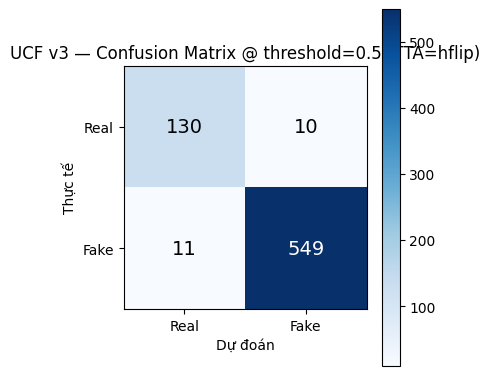

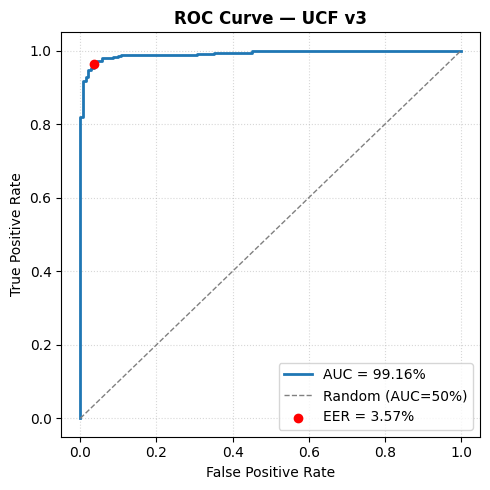

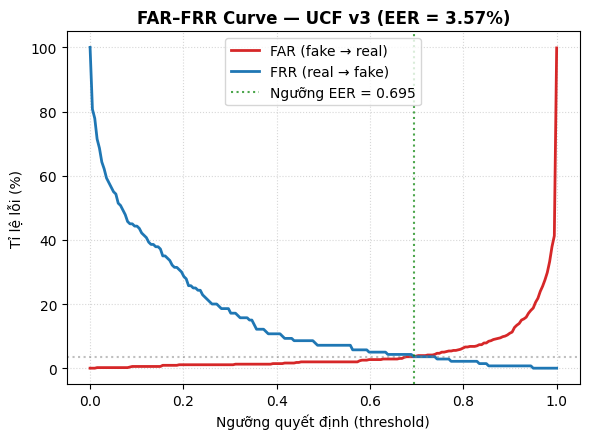


=== Breakdown theo phương pháp (real + từng loại fake) ===
        method      auc      eer   n
     Deepfakes 0.997449 0.028571 280
     Face2Face 0.995459 0.035714 280
      FaceSwap 0.997296 0.028571 280
NeuralTextures 0.976276 0.057143 280

✓ Đã lưu /kaggle/working/ucf_v3/test_results_intra.csv (schema thống nhất Phần 1 mục 5)
(Dùng đúng file CSV cùng định dạng này cho Xception/SBI/Wu et al./mô hình đề xuất để sau ghép chung thành 1 bảng so sánh — Phần 6 master prompt.)


In [7]:
ckpt = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)  # weights_only=False cần thiết từ PyTorch 2.6+
model.load_state_dict(ckpt["model_state"])
print(f"Nạp checkpoint tốt nhất từ epoch {ckpt['epoch']} "
      f"(phase={ckpt.get('phase','?')}, val_auc={ckpt['val_metrics']['auc']:.4f})")


@torch.no_grad()
def evaluate_test_tta(model, loader):
    """Giống evaluate_val() nhưng thêm TTA lật ngang (Phần 1 mục 2) và trả thêm `method` mỗi
    video để tính breakdown theo phương pháp fake."""
    model.eval()
    y_true, y_score, methods, losses = [], [], [], []
    for frames, label, method, _vid in loader:
        frames = frames.squeeze(0).to(DEVICE)               # [T, C, H, W]
        frames_flip = torch.flip(frames, dims=[3])            # lật ngang (chiều W)

        logits_orig = model.forward_inference(frames)
        logits_flip = model.forward_inference(frames_flip)

        prob_orig = F.softmax(logits_orig, dim=1)[:, 1].mean()
        prob_flip = F.softmax(logits_flip, dim=1)[:, 1].mean()
        prob = ((prob_orig + prob_flip) / 2).item()

        label_dev = torch.tensor([label.item()], dtype=torch.long, device=DEVICE)
        mean_logits = (logits_orig.mean(0, keepdim=True) + logits_flip.mean(0, keepdim=True)) / 2
        losses.append(criterion_cls(mean_logits, label_dev).item())

        y_score.append(prob); y_true.append(label.item()); methods.append(method[0])
    return np.asarray(y_true), np.asarray(y_score), np.asarray(methods), float(np.mean(losses))


y_true, y_score, methods, test_loss = evaluate_test_tta(model, test_loader)
test_metrics = calc_metrics(y_true, y_score)
test_metrics["loss"] = test_loss

print("\n=== KẾT QUẢ TEST (intra-FF++ C23) — UCF v3 baseline (TTA=hflip) ===")
print(f"Loss (CE)           : {test_metrics['loss']:.4f}")
print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"AUC                 : {test_metrics['auc']*100:.2f}%")
print(f"EER                 : {test_metrics['eer']*100:.2f}%")
print(f"FAR @ threshold=0.5 : {test_metrics['far_at_0.5']*100:.2f}%  (fake bị nhận nhầm thành real)")
print(f"FRR @ threshold=0.5 : {test_metrics['frr_at_0.5']*100:.2f}%  (real bị nhận nhầm thành fake)")
print(f"Ngưỡng tại EER      : {test_metrics['eer_threshold']:.4f}")
print(f"FAR @ ngưỡng EER    : {test_metrics['far_at_eer']*100:.2f}%")
print(f"FRR @ ngưỡng EER    : {test_metrics['frr_at_eer']*100:.2f}%")

print("\n=== Ma trận nhầm lẫn @ threshold=0.5 ===")
cm = test_metrics["cm_at_0.5"]
print("                 Dự đoán Real   Dự đoán Fake")
print(f"Thực tế Real      {cm[0,0]:>10d}   {cm[0,1]:>12d}")
print(f"Thực tế Fake      {cm[1,0]:>10d}   {cm[1,1]:>12d}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Real", "Fake"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real", "Fake"])
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title("UCF v3 — Confusion Matrix @ threshold=0.5 (TTA=hflip)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=100)
plt.show()

# ---- MỚI: ROC curve (trước đây không có -- đồng bộ với SBI/Wu/Spatial/rPPG/CAN) ----
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(test_metrics["roc_fpr"], test_metrics["roc_tpr"], lw=2, color="#1f77b4",
        label=f"AUC = {test_metrics['auc']*100:.2f}%")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Random (AUC=50%)")
ax.scatter([test_metrics["far_at_eer"]], [1 - test_metrics["frr_at_eer"]], color="red", zorder=5,
           label=f"EER = {test_metrics['eer']*100:.2f}%")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — UCF v3", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

# ---- MỚI: FAR-FRR curve (trước đây không có) ----
thr, fars, frrs = calc_far_frr_curve(y_true, y_score)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thr, fars * 100, lw=2, color="#d62728", label="FAR (fake → real)")
ax.plot(thr, frrs * 100, lw=2, color="#1f77b4", label="FRR (real → fake)")
ax.axvline(test_metrics["eer_threshold"], color="green", ls=":", alpha=0.7,
           label=f"Ngưỡng EER = {test_metrics['eer_threshold']:.3f}")
ax.axhline(test_metrics["eer"] * 100, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Ngưỡng quyết định (threshold)"); ax.set_ylabel("Tỉ lệ lỗi (%)")
ax.set_title(f"FAR–FRR Curve — UCF v3 (EER = {test_metrics['eer']*100:.2f}%)", fontweight="bold")
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "far_frr_curve.png"), dpi=150)
plt.show()

# ---- Breakdown AUC/EER theo từng phương pháp fake (real luôn gộp cùng để tính nhị phân) ----
rows = []
real_mask = (methods == "original")
for m in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
    mask = real_mask | (methods == m)
    yt, ys = y_true[mask], y_score[mask]
    if len(np.unique(yt)) < 2:
        rows.append({"method": m, "auc": float("nan"), "eer": float("nan"), "n": int(mask.sum())})
        continue
    rows.append({"method": m, "auc": roc_auc_score(yt, ys), "eer": calc_eer(yt, ys), "n": int(mask.sum())})

bd = pd.DataFrame(rows)
print("\n=== Breakdown theo phương pháp (real + từng loại fake) ===")
print(bd.to_string(index=False))

# ---- gpu_hours: cộng dồn thời gian mỗi epoch đã log trong training loop (EPOCH_TIMES) ----
gpu_hours = float(np.sum(EPOCH_TIMES)) / 3600.0

result_row = {
    "model": "UCF", "input_modality": "spatial_rgb",
    "params_M": round(n_params / 1e6, 2),
    "epochs_planned": N_EPOCHS, "epochs_run": int(hist_df["epoch"].max()),
    "best_epoch": int(ckpt["epoch"]), "checkpoint_criterion": CHECKPOINT_CRITERION,
    "tta_used": TTA_USED, "gpu_hours": round(gpu_hours, 2),
    "loss_intra": test_metrics["loss"], "acc_intra": test_metrics["acc"],
    "auc_intra": test_metrics["auc"], "eer_intra": test_metrics["eer"],
    "far_at_0.5_intra": test_metrics["far_at_0.5"], "frr_at_0.5_intra": test_metrics["frr_at_0.5"],
    "far_at_eer_intra": test_metrics["far_at_eer"], "frr_at_eer_intra": test_metrics["frr_at_eer"],
    "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
}
for _, r in bd.iterrows():
    result_row[f"auc_{r['method']}"] = r["auc"]
    result_row[f"eer_{r['method']}"] = r["eer"]

pd.DataFrame([result_row]).to_csv(os.path.join(OUT_DIR, "test_results_intra.csv"), index=False)
print(f"\n✓ Đã lưu {OUT_DIR}/test_results_intra.csv (schema thống nhất Phần 1 mục 5)")
print("(Dùng đúng file CSV cùng định dạng này cho Xception/SBI/Wu et al./mô hình đề xuất "
      "để sau ghép chung thành 1 bảng so sánh — Phần 6 master prompt.)")


---
### 🔧 Sửa cách vẽ biểu đồ — KHÔNG đổi bất kỳ hyperparameter/thiết lập training nào

Panel đầu tiên so sánh **2 đại lượng loss khác thang đo**: `train_loss` (tổng 4 thành phần
multi-task, chủ yếu là reconstruction) so với `val_loss` (chỉ 1 mình classification loss) — về
bản chất không thể "bám sát nhau" vì đo 2 thứ khác nhau, không liên quan gì đến việc model học
đúng hay sai.

**Sửa duy nhất:** đổi panel đầu tiên sang so sánh `train_ce_c` (loss phân loại common, CHƯA
nhân trọng số) với `val_loss` (cũng là loss phân loại common) — cùng 1 đại lượng, sẽ thấy 2
đường bám sát nhau đúng như kỳ vọng. Không đụng vào bất kỳ dòng code training/hyperparameter
nào — giữ nguyên đúng paper.
---

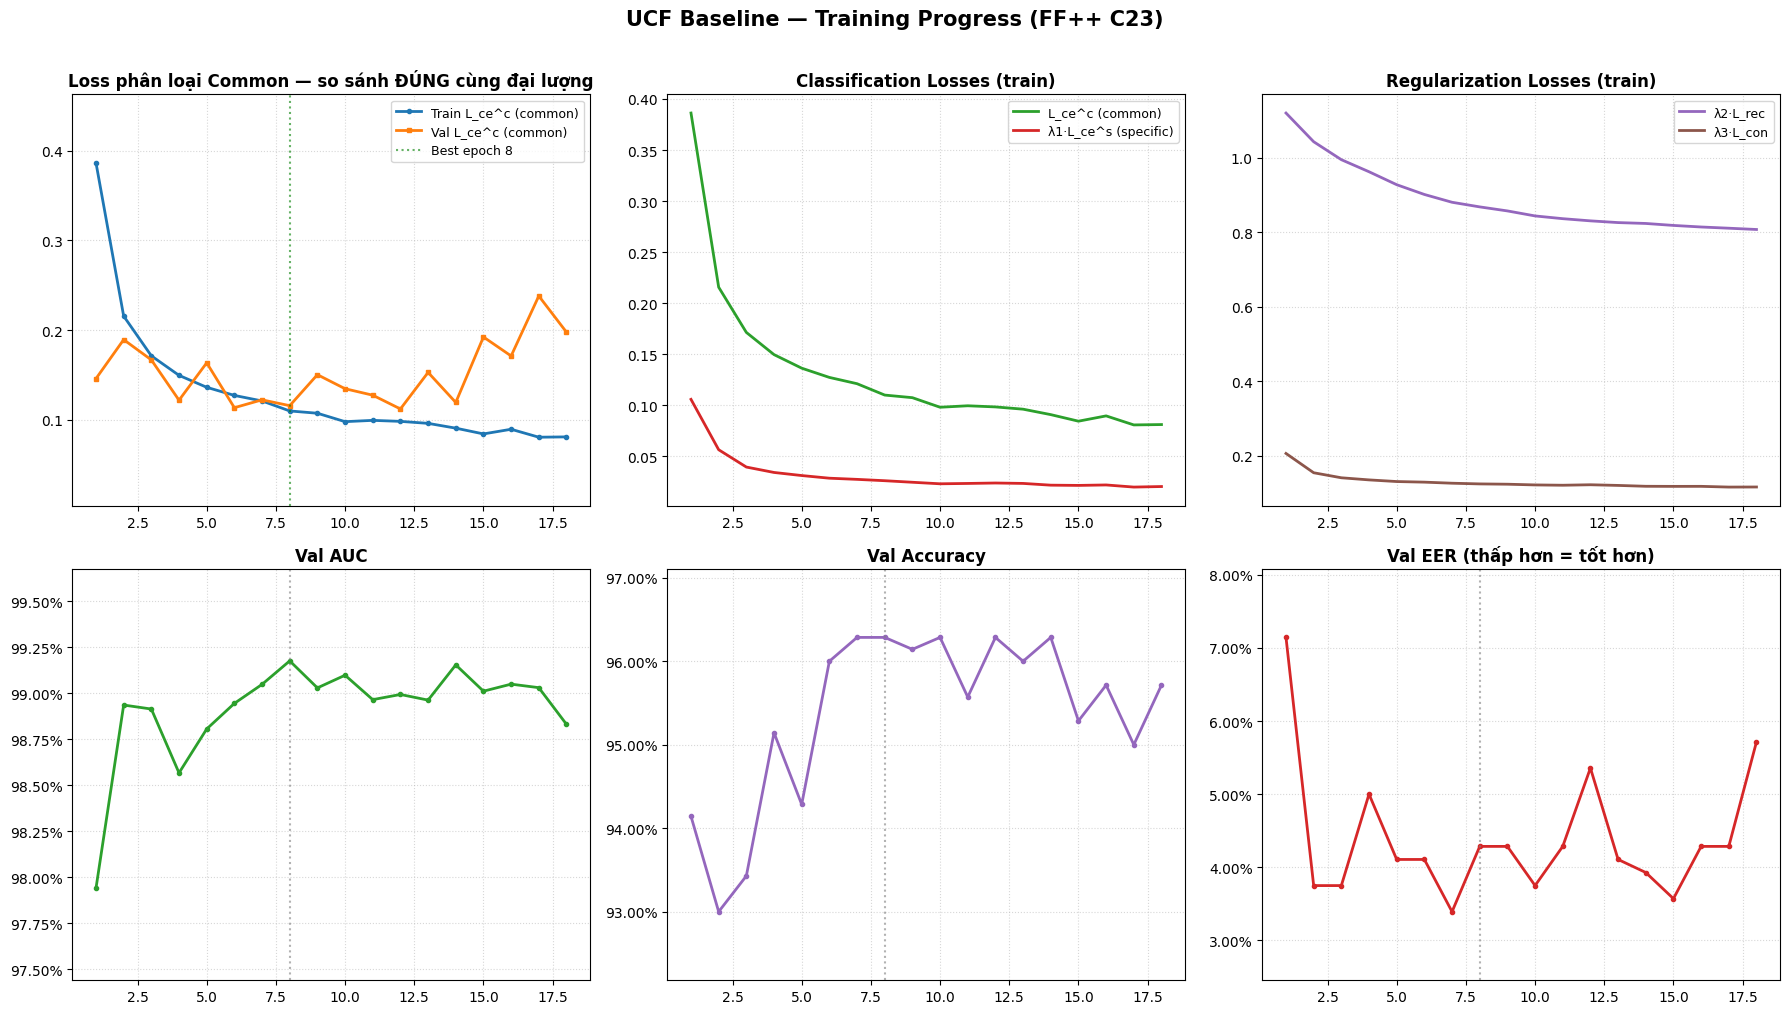

Best epoch: 8 — val_auc=0.9918 val_acc=0.9629 val_eer=0.0429

Luu y: val_loss chi do L_ce^c (loss phan loai thuan) de so sanh cong bang voi train_ce_c -- KHONG bao gom reconstruction/contrastive nhu train_loss tong, day la ly do bieu do ban truoc trong khong khop du model hoc dung.


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

hist_df = pd.read_csv(os.path.join(OUT_DIR, "train_history.csv"))
x = hist_df["epoch"]
best_idx = hist_df["val_auc"].idxmax()
best_epoch = hist_df.loc[best_idx, "epoch"]

def dynamic_ylim(series, floor_pad):
    lo, hi = series.min(), series.max()
    pad = max((hi - lo) * 0.25, floor_pad)
    return lo - pad, hi + pad

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(x, hist_df["train_ce_c"], "o-", lw=2, ms=3, label="Train L_ce^c (common)", color="#1f77b4")
axes[0,0].plot(x, hist_df["val_loss"], "s-", lw=2, ms=3, label="Val L_ce^c (common)", color="#ff7f0e")
axes[0,0].axvline(best_epoch, color="green", linestyle=":", alpha=0.6, label=f"Best epoch {int(best_epoch)}")
lo, hi = dynamic_ylim(pd.concat([hist_df["train_ce_c"], hist_df["val_loss"]]), 0.02)
axes[0,0].set_ylim(lo, hi)
axes[0,0].set_title("Loss phân loại Common — so sánh ĐÚNG cùng đại lượng", fontweight="bold")
axes[0,0].legend(fontsize=9); axes[0,0].grid(True, ls=":", alpha=0.5)

axes[0,1].plot(x, hist_df["train_ce_c"], lw=2, label="L_ce^c (common)", color="#2ca02c")
axes[0,1].plot(x, hist_df["train_ce_s"], lw=2, label="λ1·L_ce^s (specific)", color="#d62728")
axes[0,1].set_title("Classification Losses (train)", fontweight="bold")
axes[0,1].legend(fontsize=9); axes[0,1].grid(True, ls=":", alpha=0.5)

axes[0,2].plot(x, hist_df["train_rec"], lw=2, label="λ2·L_rec", color="#9467bd")
axes[0,2].plot(x, hist_df["train_con"], lw=2, label="λ3·L_con", color="#8c564b")
axes[0,2].set_title("Regularization Losses (train)", fontweight="bold")
axes[0,2].legend(fontsize=9); axes[0,2].grid(True, ls=":", alpha=0.5)

axes[1,0].plot(x, hist_df["val_auc"] * 100, "o-", lw=2, ms=3, color="#2ca02c")
axes[1,0].axvline(best_epoch, color="gray", linestyle=":", alpha=0.6)
lo, hi = dynamic_ylim(hist_df["val_auc"] * 100, 0.5)
axes[1,0].set_ylim(lo, hi)
axes[1,0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
axes[1,0].set_title("Val AUC", fontweight="bold"); axes[1,0].grid(True, ls=":", alpha=0.5)

axes[1,1].plot(x, hist_df["val_acc"] * 100, "o-", lw=2, ms=3, color="#9467bd")
axes[1,1].axvline(best_epoch, color="gray", linestyle=":", alpha=0.6)
lo, hi = dynamic_ylim(hist_df["val_acc"] * 100, 0.5)
axes[1,1].set_ylim(lo, hi)
axes[1,1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
axes[1,1].set_title("Val Accuracy", fontweight="bold"); axes[1,1].grid(True, ls=":", alpha=0.5)

axes[1,2].plot(x, hist_df["val_eer"] * 100, "o-", lw=2, ms=3, color="#d62728")
axes[1,2].axvline(best_epoch, color="gray", linestyle=":", alpha=0.6)
lo, hi = dynamic_ylim(hist_df["val_eer"] * 100, 0.5)
axes[1,2].set_ylim(lo, hi)
axes[1,2].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
axes[1,2].set_title("Val EER (thấp hơn = tốt hơn)", fontweight="bold"); axes[1,2].grid(True, ls=":", alpha=0.5)

plt.suptitle("UCF Baseline — Training Progress (FF++ C23)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

best_ep = hist_df.loc[best_idx]
print(f"Best epoch: {int(best_ep['epoch'])} — val_auc={best_ep['val_auc']:.4f} "
      f"val_acc={best_ep['val_acc']:.4f} val_eer={best_ep['val_eer']:.4f}")
print("\nLuu y: val_loss chi do L_ce^c (loss phan loai thuan) de so sanh cong bang voi "
      "train_ce_c -- KHONG bao gom reconstruction/contrastive nhu train_loss tong, day la "
      "ly do bieu do ban truoc trong khong khop du model hoc dung.")


## ⚠️ Lưu kết quả
**Save Version → Save & Run All (Commit)** → Output → New Dataset

Sau khi chạy xong, thư mục `/kaggle/working/ucf_v3/` sẽ có đủ:
- `ucf_best.pth` — checkpoint tốt nhất theo `val_auc`
- `train_history.csv` — log mỗi epoch (đúng schema thống nhất, cột `stage`)
- `test_results_intra.csv` — kết quả test đầy đủ (đúng schema thống nhất 5 model, **MỚI THÊM**)
- `confusion_matrix.png`, `training_curves.png`
